### Aspect ratio plots

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import kruskal

In [3]:
# path
DATA_DIR = '../data'

ar_chir_act_file = 'aspect_ratio_chir_vs_act.xlsx'
ar_act_144h_file = 'aspect_ratio_act_144h.xlsx'

# results
PLOTS_DIR = '../results/violin'
os.makedirs(PLOTS_DIR, exist_ok=True)


In [4]:
# load data (aspect ratio gastruloid measurements)
# chir vs act
ar_chir_act = pd.read_excel(f"{DATA_DIR}/{ar_chir_act_file}")
ar_chir_act_ = ar_chir_act.melt(
    var_name="condition",
    value_name="aspect_ratio"
)
# acta
ar_act_144h = pd.read_excel(f"{DATA_DIR}/{ar_act_144h_file}")
ar_act_144h_ = ar_act_144h.melt(
    var_name="condition",
    value_name="aspect_ratio"
)


### Violin plots
- Plot aspect ratio per conditiona and perform Mann-Whitney test for statistical significance

#### CHIR vs ActA

/tmp/ipykernel_46730/2391942683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


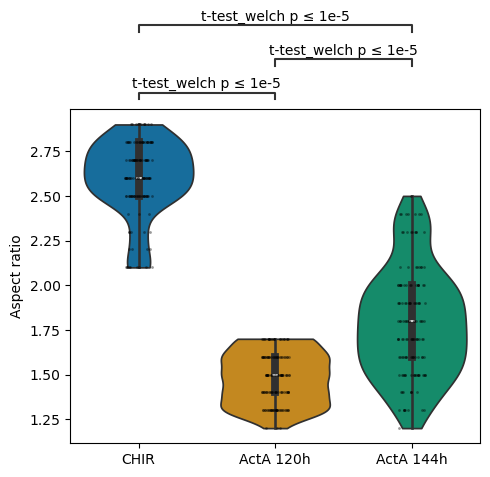

In [6]:
order = ["CHIR", "ActA 120h", "ActA 144h"]

palette = sns.color_palette("colorblind", 3)

plt.figure(figsize=(5,5))

ax = sns.violinplot(
    data=ar_chir_act_,
    x="condition",
    y="aspect_ratio",
    order=order,
    inner="box",
    cut=0,
    palette=palette
)

sns.stripplot(
    data=ar_chir_act_,
    x="condition",
    y="aspect_ratio",
    order=order,
    color="black",
    size=2,
    alpha=0.4
)

# pairwise comparisons
pairs = [
    ("CHIR", "ActA 120h"),
    ("CHIR", "ActA 144h"),
    ("ActA 120h", "ActA 144h")
]

annotator = Annotator(
    ax,
    pairs,
    data=ar_chir_act_,
    x="condition",
    y="aspect_ratio",
    order=order
)

annotator.configure(
    test="t-test_welch",
    text_format="simple",     # <-- this shows p = 0.xxx
    comparisons_correction="bonferroni",
    loc="outside",
    line_height=0.02,
    verbose=0
)

annotator.apply_and_annotate()

plt.ylabel("Aspect ratio")
plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/ar_chir_vs_acta.svg")
plt.show()



#### ActA dose

/tmp/ipykernel_46730/858145528.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


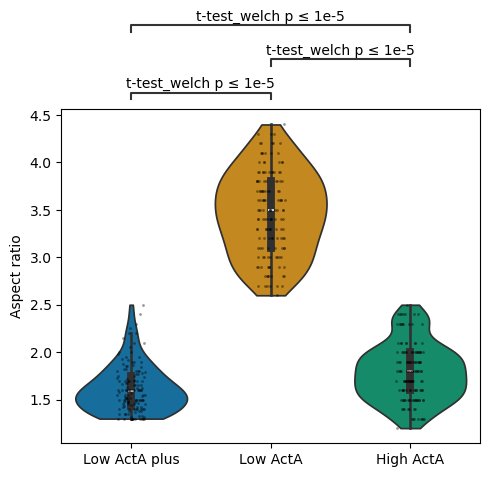

In [14]:
order = ["Low ActA plus", "Low ActA", "High ActA"]

palette = sns.color_palette("colorblind", 3)

plt.figure(figsize=(5,5))

ax = sns.violinplot(
    data=ar_act_144h_,
    x="condition",
    y="aspect_ratio",
    order=order,
    inner="box",
    cut=0,
    palette=palette
)

sns.stripplot(
    data=ar_act_144h_,
    x="condition",
    y="aspect_ratio",
    order=order,
    color="black",
    size=2,
    alpha=0.4
)

# pairwise comparisons
pairs = [
    ("Low ActA plus", "Low ActA"),
    ("Low ActA plus", "High ActA"),
    ("Low ActA", "High ActA")
]

annotator = Annotator(
    ax,
    pairs,
    data=ar_act_144h_,
    x="condition",
    y="aspect_ratio",
    order=order
)

annotator.configure(
    test="t-test_welch",
    text_format="simple",     # <-- this shows p = 0.xxx
    comparisons_correction="bonferroni",
    loc="outside",
    line_height=0.02,
    verbose=0
)

annotator.apply_and_annotate()

plt.ylabel("Aspect ratio")
plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/ar_acta_144h.svg")
plt.show()



In [18]:
from scipy.stats import ttest_ind

pairs = [
    ("Low ActA plus", "Low ActA"),
    ("Low ActA plus", "High ActA"),
    ("Low ActA", "High ActA")
]

results = []

for g1, g2 in pairs:
    x = ar_act_144h_.query("condition == @g1")["aspect_ratio"]
    y = ar_act_144h_.query("condition == @g2")["aspect_ratio"]

    stat, p = ttest_ind(x, y, equal_var=False)
    results.append((g1, g2, p))

# Bonferroni correction
m = len(results)

for g1, g2, p in results:
    p_bonf = min(p * m, 1.0)
    print(f"{g1} vs {g2}: raw p = {p:.4g}, Bonferroni p = {p_bonf:.4g}")


Low ActA plus vs Low ActA: raw p = 1.637e-112, Bonferroni p = 4.91e-112
Low ActA plus vs High ActA: raw p = 1.665e-07, Bonferroni p = 4.996e-07
Low ActA vs High ActA: raw p = 9.787e-106, Bonferroni p = 2.936e-105


In [19]:
import pingouin as pg

pg.welch_anova(
    data=ar_act_144h_,
    dv="aspect_ratio",
    between="condition"
)


,Source,ddof1,ddof2,F,p-unc,np2
0,condition,2,274.076835,1000.874337,1.059634e-126,0.858865


In [20]:
pg.pairwise_ttests(
    data=ar_act_144h_,
    dv="aspect_ratio",
    between="condition",
    parametric=True,
    padjust="bonf",
    effsize="hedges"
)


/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,condition,High ActA,Low ActA,False,True,-37.755113,286.0,two-sided,4.000311e-113,1.200093e-112,bonf,1.039e+109,-4.437804
1,condition,High ActA,Low ActA plus,False,True,5.370665,286.0,two-sided,1.626437e-07,4.879312e-07,bonf,7.263e+04,0.631278
2,condition,Low ActA,Low ActA plus,False,True,43.914942,286.0,two-sided,3.876858e-129,1.163058e-128,bonf,8.872e+124,5.161842
